In [16]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importar librerías
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1. Cargar el dataset Iris
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

# Cargar dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})


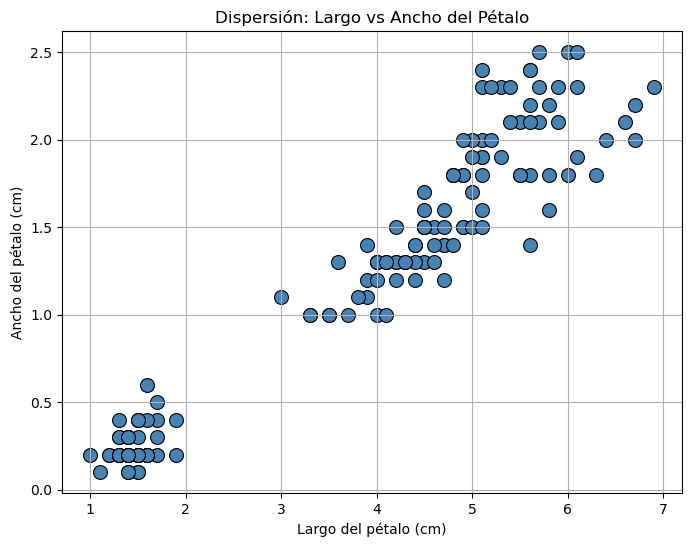

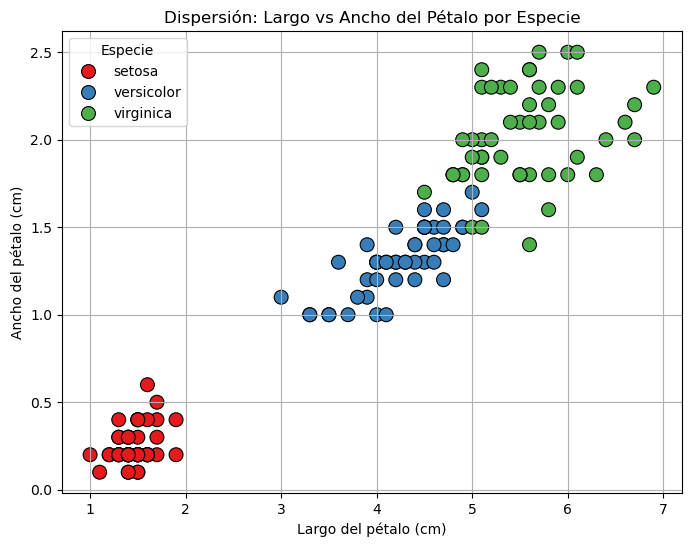

In [12]:
# Gráfico de dispersión: largo vs ancho del pétalo
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="target_name",
    palette="Set1",
    s=100,
    edgecolor="black"
)
plt.title("Dispersión: Largo vs Ancho del Pétalo por Especie")
plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.legend(title="Especie")
plt.grid(True)
plt.show()

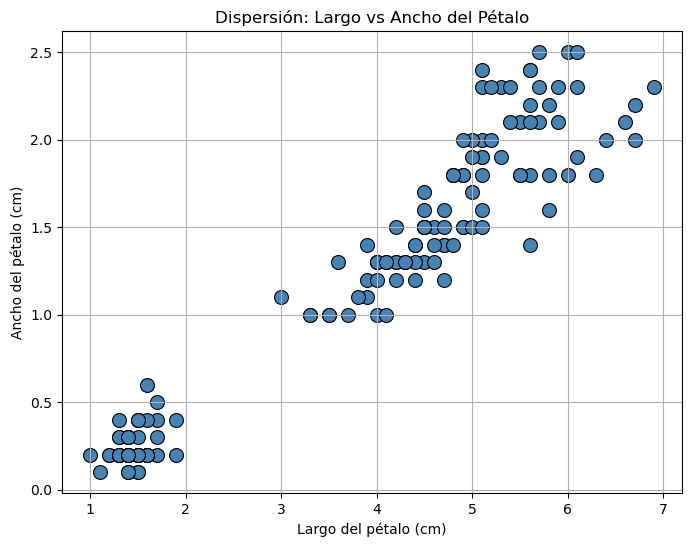

In [20]:
# Gráfico de dispersión: largo vs ancho del pétalo (sin etiquetas de especie)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    color="steelblue",   # un solo color
    s=100,
    edgecolor="black"
)
plt.title("Dispersión: Largo vs Ancho del Pétalo")
plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.grid(True)
plt.show()

In [22]:
#  Paso 2: Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

df = df.drop(columns=['target'])  # RETIRADAS DE ETIQUETAS 
df = df.drop(columns=['target_name'])   # RETIRADAS DE ETIQUETAS 

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [27]:
# ===== 1) Seleccionar solo features numéricos (sin la columna de especie) =====
if 'target_name' in df.columns:
    feature_cols = [c for c in df.columns if c != 'target_name']
else:
    feature_cols = df.select_dtypes(include='number').columns.tolist()

X = df[feature_cols].copy()

# ===== 2) Escalado =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===== 3) K-Means (k=3) =====
k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'] = pd.Series(km_labels, index=df.index).astype(int).astype(str)  # como string para plot

# ===== 4) Jerárquico aglomerativo (Ward, k=3) =====
agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

df['hclust_cluster'] = pd.Series(agg_labels, index=df.index).astype(int).astype(str)

# ===== 5) Métrica rápida de calidad (silhouette) =====
sil_km  = silhouette_score(X_scaled, km_labels)
sil_hcl = silhouette_score(X_scaled, agg_labels)
print(f"Silhouette K-Means: {sil_km:.3f}")
print(f"Silhouette Jerárquico: {sil_hcl:.3f}")


Silhouette K-Means: 0.460
Silhouette Jerárquico: 0.447


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


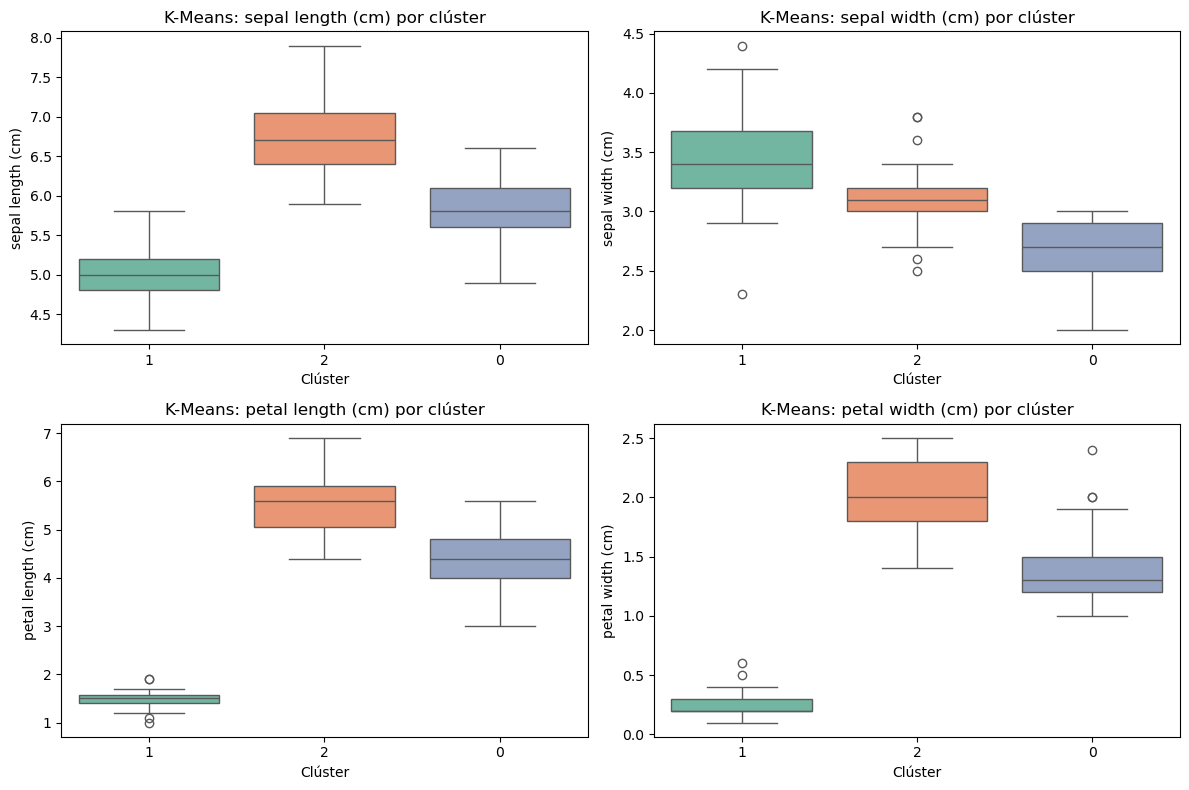

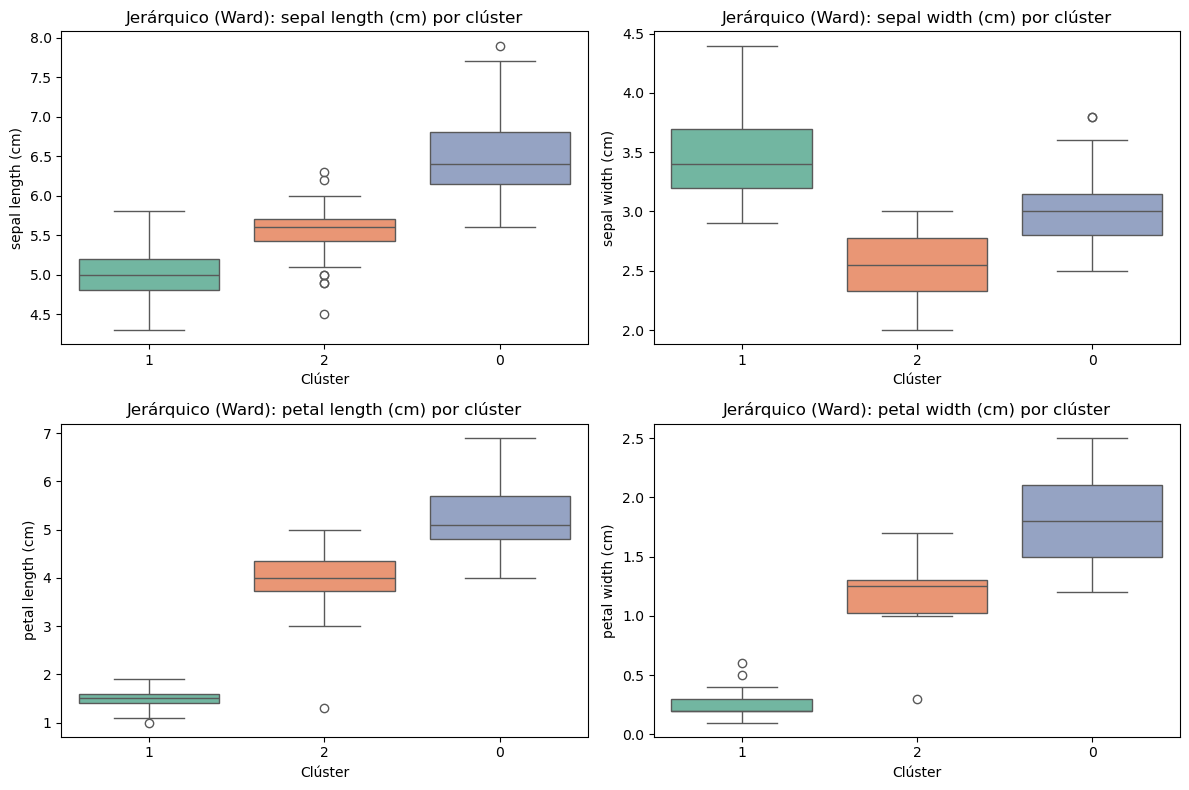

In [29]:
# ===== 6) Función para boxplots por clúster =====
def boxplots_por_cluster(dataframe, group_col, title_prefix):
    num_features = len(feature_cols)
    rows = math.ceil(num_features / 2)

    plt.figure(figsize=(12, 4*rows))
    for i, col in enumerate(feature_cols, 1):
        plt.subplot(rows, 2, i)
        # Evita FutureWarning: usar palette con hue y sin leyenda
        sns.boxplot(x=group_col, y=col, data=dataframe,
                    hue=group_col, palette="Set2", legend=False)
        plt.title(f"{title_prefix}: {col} por clúster")
        plt.xlabel("Clúster")
        plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ===== 7) Graficar =====
boxplots_por_cluster(df, 'kmeans_cluster', "K-Means")
boxplots_por_cluster(df, 'hclust_cluster', "Jerárquico (Ward)")

In [41]:
from itertools import combinations
import math

def scatter_pairs_por_cluster(df, features, label_col, titulo, max_pairs=None, ncols=3):
    """
    Dibuja nubes de puntos para todas (o hasta max_pairs) combinaciones de pares de features,
    coloreadas por la columna de etiquetas 'label_col'.
    """
    pares = list(combinations(features, 2))
    if max_pairs is not None:
        pares = pares[:max_pairs]
    n = len(pares)
    if n == 0:
        print("No hay pares de variables para graficar.")
        return

    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(5*ncols, 4*nrows))

    # Para que la leyenda no se repita en todos, solo en el primer subplot
    for i, (xcol, ycol) in enumerate(pares, start=1):
        ax = plt.subplot(nrows, ncols, i)
        sns.scatterplot(
            data=df, x=xcol, y=ycol, hue=label_col,
            palette='Set2', s=50, edgecolor='white', linewidth=0.4, ax=ax
        )
        ax.set_title(f"{titulo}: {ycol} vs {xcol}")
        if i != 1:
            ax.legend_.remove()  # quita leyendas duplicadas

    # Leyenda única al costado
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left', title='Clúster')
    plt.tight_layout()
    plt.show()

# === Llamadas (usa features originales, NO PCA) ===




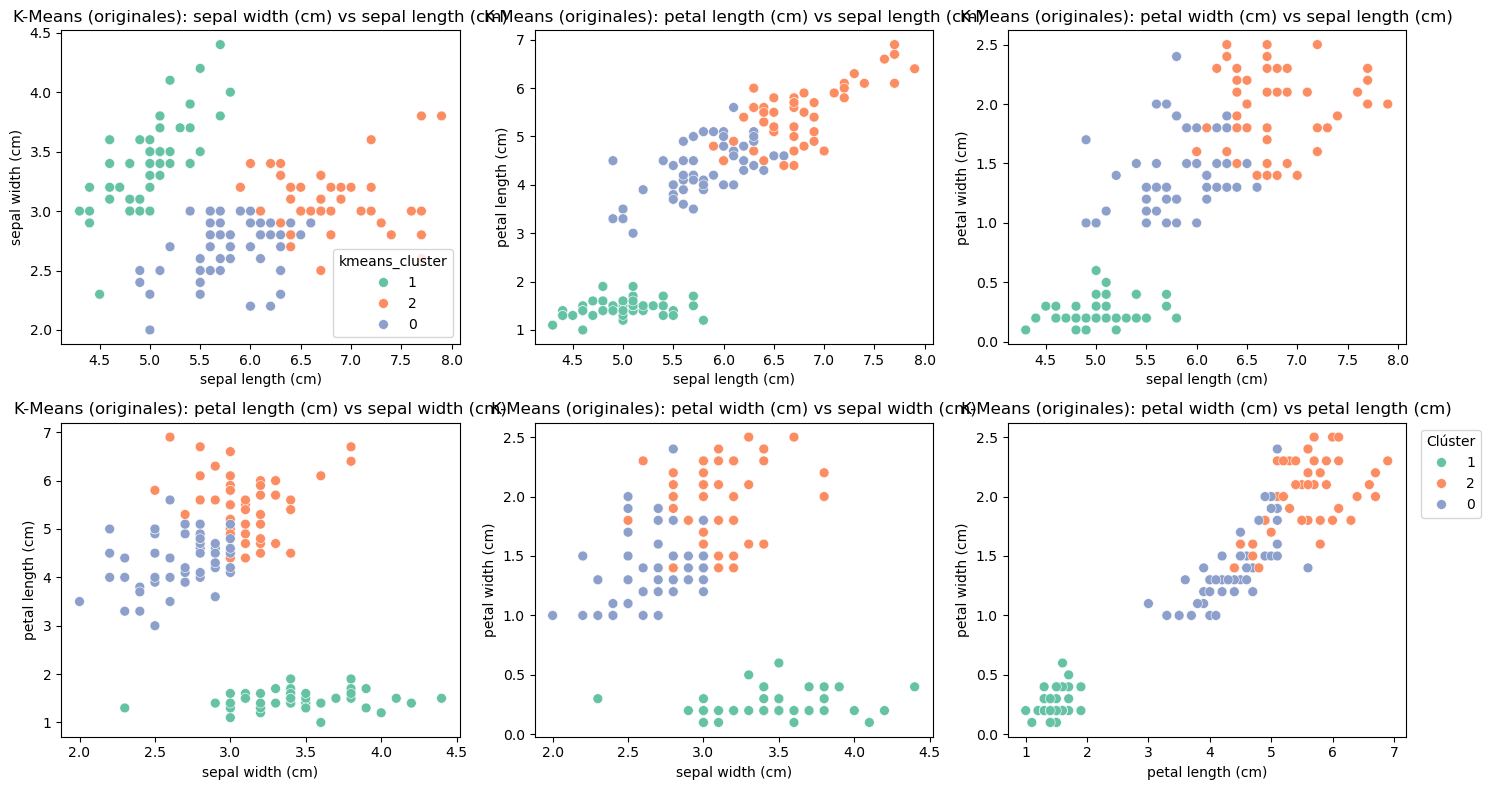

In [39]:
scatter_pairs_por_cluster(df, feature_cols, 'kmeans_cluster', "K-Means (originales)")

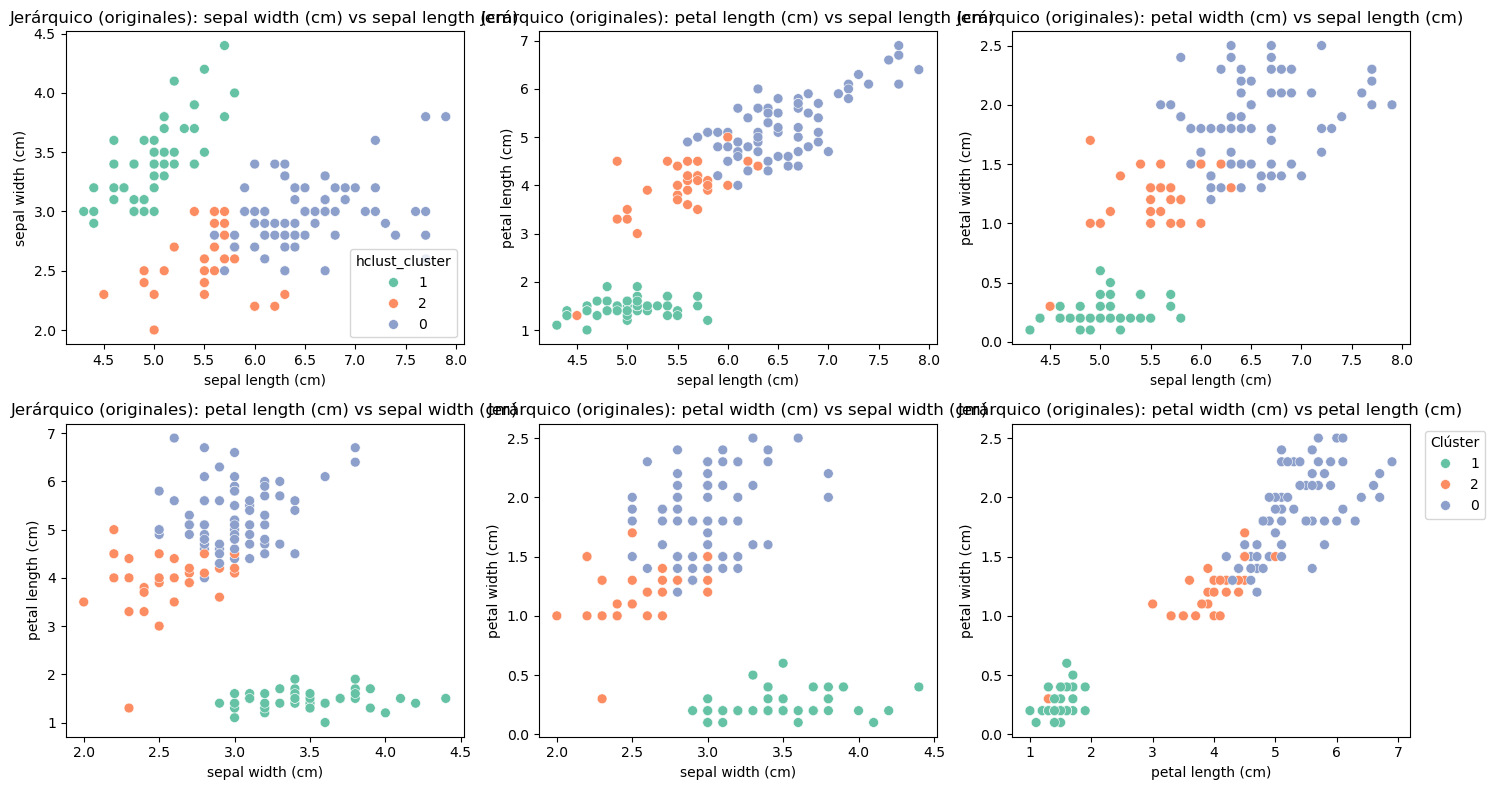

In [35]:
scatter_pairs_por_cluster(df, feature_cols, 'hclust_cluster', "Jerárquico (originales)")

In [43]:
from sklearn.decomposition import PCA

# Reducir a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)

# Guardar en df
df['PC1'] = Z[:, 0]
df['PC2'] = Z[:, 1]

print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)

Varianza explicada por PC1 y PC2: [0.72962445 0.22850762]


In [49]:
def scatter_clusters_pca(dataframe, cluster_col, titulo, centroids=None):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=dataframe, x='PC1', y='PC2',
        hue=cluster_col, palette='Set2', s=60, edgecolor='white', linewidth=0.6
    )
    plt.title(titulo)
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    # Dibujar centroides (solo en K-Means)
    if centroids is not None:
        C = pca.transform(centroids)  # proyectar centroides al espacio PCA
        plt.scatter(C[:, 0], C[:, 1], marker='X', s=200, color='black', label='Centroides')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Clúster")

    plt.tight_layout()
    plt.show()

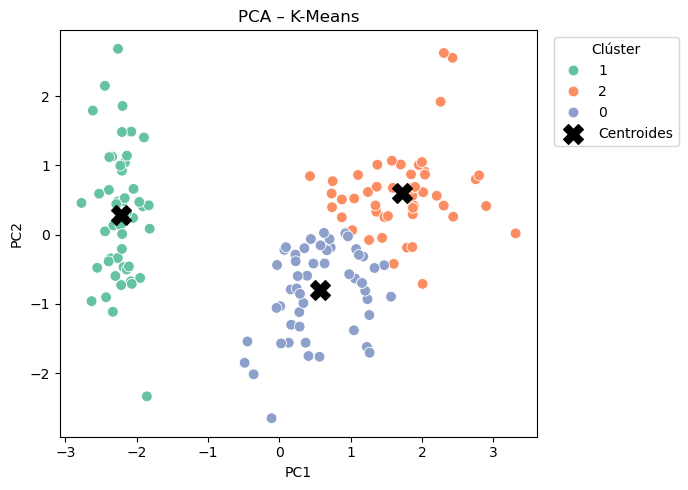

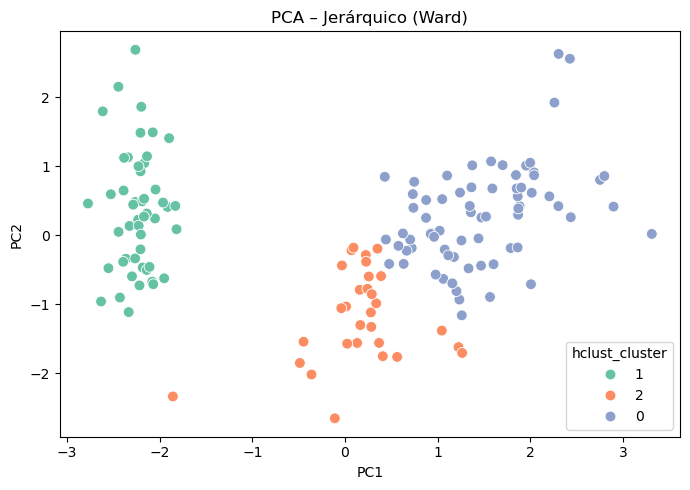

In [51]:
# K-Means (con centroides proyectados)
scatter_clusters_pca(df, 'kmeans_cluster', "PCA – K-Means", centroids=kmeans.cluster_centers_)

# Jerárquico (sin centroides)
scatter_clusters_pca(df, 'hclust_cluster', "PCA – Jerárquico (Ward)")

# 📌 Clustering Jerárquico – Método de Ward

El **clustering jerárquico** es una técnica de agrupamiento que construye una jerarquía de clústeres a través de un proceso **aglomerativo** (bottom-up):

1. Cada observación comienza como su propio clúster individual.
2. En cada iteración, se combinan los **dos clústeres más similares** en uno solo.
3. El proceso continúa hasta que todos los puntos quedan unidos en un único clúster, formando un **dendrograma**.

---

## 🔎 Método de Ward
El método de **Ward** es una estrategia específica para decidir **qué clústeres unir** en cada paso.  
Su criterio es **minimizar el incremento en la varianza intra-clúster** (o suma de cuadrados dentro de los grupos).  

En otras palabras:
- Busca que, al fusionar dos clústeres, la **pérdida de homogeneidad interna sea la menor posible**.
- A diferencia de otros métodos (como "single-link" o "complete-link"), Ward favorece la formación de clústeres **compactos y de tamaño similar**.

---

## ✨ Características del método de Ward
- Produce clústeres más equilibrados en comparación con otros criterios.
- Tiende a generar clústeres **esféricos** cuando se usan distancias euclidianas.
- Es sensible a la escala de los datos, por lo que es recomendable **estandarizar las variables** antes de aplicarlo.

---

## 📊 Visualización
El resultado puede representarse en un **dendrograma**, que muestra cómo se fueron uniendo los clústeres paso a paso.  
Para cortar el dendrograma y definir un número de clústeres específico (por ejemplo, 3), se elige un **nivel de altura** en el árbol.


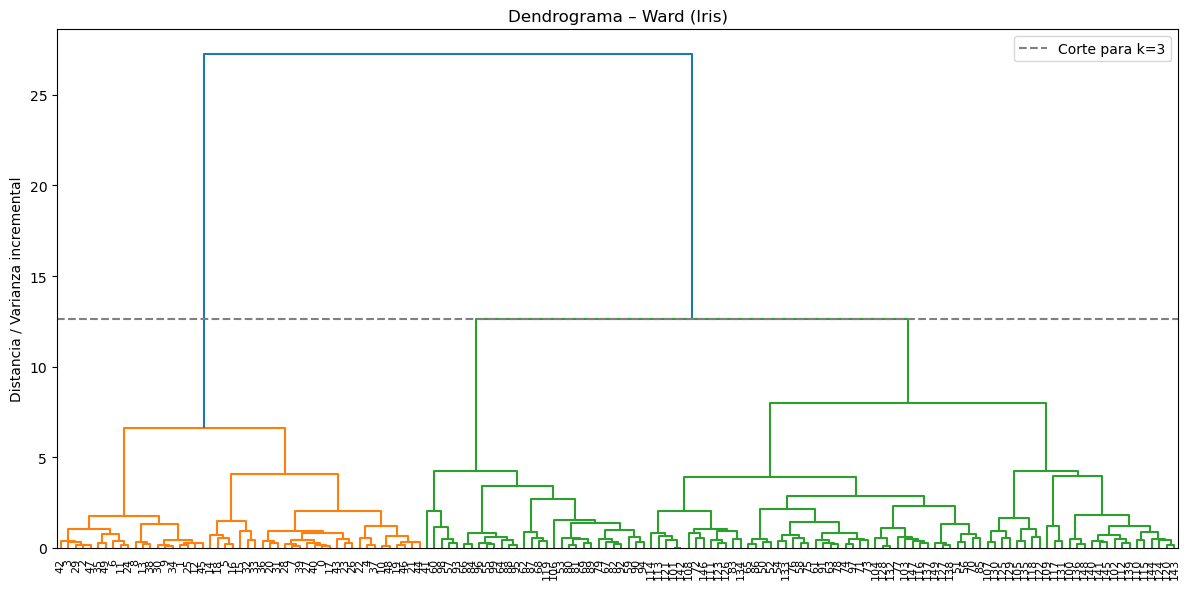

In [6]:
# Celda: Dendrograma completo (Ward)
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Enlace jerárquico con Ward (usa distancia euclidiana internamente)
Z = linkage(X_scaled, method='ward')

# Etiquetas: usa especie si está disponible, si no, el índice
labels = df['target_name'].values if 'target_name' in df.columns else df.index.astype(str).values

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=labels,
    leaf_rotation=90,   # gira etiquetas si son largas
    leaf_font_size=8
)
plt.title("Dendrograma – Ward (Iris)")
plt.ylabel("Distancia / Varianza incremental")

# Línea de corte para k=3 (aprox. a la altura del último (k-1) merge)
k = 3
thr = Z[-(k-1), 2]
plt.axhline(y=thr, linestyle='--', color='gray', label=f'Corte para k={k}')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
